In [1]:
import pandas as pd
import sys

sys.path.append("..")

from src.estimator import Estimator

In [2]:
df = pd.read_csv("../data/clean/dataset.csv")

df.head()

,number,title,is_pr,state,created_at,closed_at,days_to_close,labels,has_bug,has_enhancement,merged,user_login
0,65717,CI: Update pixi.lock,True,closed,2026-05-24 05:34:32+00:00,2026-05-24 17:43:48+00:00,0,CI,False,False,True,github-actions[bot]
1,65716,BUG: DataFrame.update warns when index dtype m...,True,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NaN,False,False,False,hiraddlz
2,65697,"Revert ""BUG: reject unhashable elements in Ind...",True,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0,Index,False,False,True,jorisvandenbossche
3,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,True,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,NaN,False,False,True,jorisvandenbossche
4,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,True,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,0,NaN,False,False,False,kjmin622


In [3]:
df.columns

Index(['number', 'title', 'is_pr', 'state', 'created_at', 'closed_at',
       'days_to_close', 'labels', 'has_bug', 'has_enhancement', 'merged',
       'user_login'],
      dtype='str')

In [4]:
pr_df = df[df["is_pr"] == True]

pr_df.head()

,number,title,is_pr,state,created_at,closed_at,days_to_close,labels,has_bug,has_enhancement,merged,user_login
0,65717,CI: Update pixi.lock,True,closed,2026-05-24 05:34:32+00:00,2026-05-24 17:43:48+00:00,0,CI,False,False,True,github-actions[bot]
1,65716,BUG: DataFrame.update warns when index dtype m...,True,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NaN,False,False,False,hiraddlz
2,65697,"Revert ""BUG: reject unhashable elements in Ind...",True,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0,Index,False,False,True,jorisvandenbossche
3,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,True,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,NaN,False,False,True,jorisvandenbossche
4,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,True,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,0,NaN,False,False,False,kjmin622


In [5]:
total_pr = len(pr_df)

merged_count = pr_df["merged"].sum()

print("Total PR:", total_pr)
print("Merged PR:", merged_count)

Total PR: 2592
Merged PR: 1789


In [6]:
estimator = Estimator()

mle = estimator.mle_merge_probability(
    merged_count,
    total_pr
)

print("MLE Merge Probability:", mle)

MLE Merge Probability: 0.6902006172839507


In [7]:
failure = total_pr - merged_count

alpha, beta_param = estimator.beta_posterior(
    merged_count,
    failure
)

print("Posterior Alpha:", alpha)
print("Posterior Beta:", beta_param)

Posterior Alpha: 1790
Posterior Beta: 804


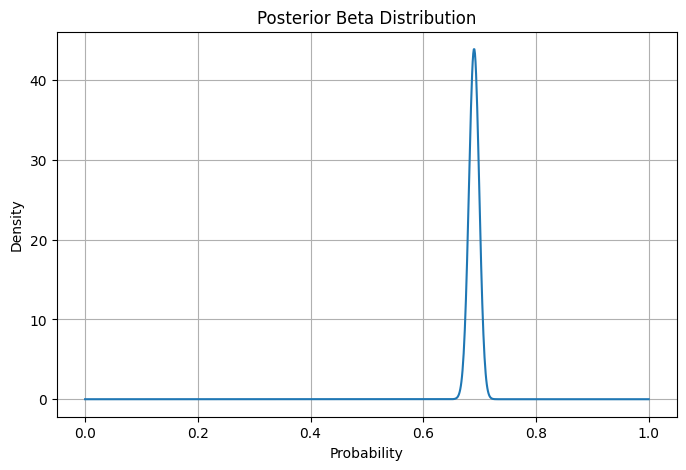

In [8]:
estimator.plot_beta_distribution(
    alpha,
    beta_param
)